# Loading and preparing data
kaggle notebook can be found under this link: https://www.kaggle.com/code/klagony/qwen-finetuning-lora

In [3]:
from datasets import load_dataset

train_ds = load_dataset("json", data_files="/kaggle/input/datasets/klagony/cuad-clauses/clauses_train.jsonl", split="train")
test_ds = load_dataset("json", data_files="/kaggle/input/datasets/klagony/cuad-clauses/clauses_test.jsonl", split="train")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
from datasets import Dataset

CATEGORIES = set(train_ds["label"])
SYSTEM_PROMT = f"You are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation from the following list: {CATEGORIES}"

def convert_to_conversation(sample):
    return {
        "messages": [
            {"role": "system",  "content": SYSTEM_PROMT},
            {"role": "user",    "content": str(sample["text"])},
            {"role": "assistant", "content": str(sample["label"])},
        ]
    }

converted_dataset = Dataset.from_list([convert_to_conversation(sample) for sample in train_ds])
print(converted_dataset[0])

{'messages': [{'role': 'system', 'content': "You are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation from the following list: {'anti_assignment', 'exclusivity', 'insurance_required', 'governing_law', 'liability_cap', 'minimum_commitment', 'non_compete', 'audit_rights'}"}, {'role': 'user', 'content': 'In the event of termination by either party in accordance with any of the provisions of this Agreement, neither party shall be liable to the other, because of such termination, for compensation, reimbursement or damages on account of the loss of prospective profits or anticipated sales or on account of expenditures, inventory, investments, leases or commitments in connection with the business or goodwill of E.piphany or HSNS.'}, {'role': 'assistant', 'content': 'liability_cap'}]}


# Finetuning 
- QLoRa is not recommended for finetuning the qwen3.5 model due to highter than normal quantization differences -> LoRa 

In [6]:
!pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 25.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.2 MB/s eta 0:00:

In [23]:
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

 
def finetune_model(model_name, train_ds, r, lora_alpha, lora_dropout, target_modules, lr):
    
    #loading the model and tokenizer
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name = model_name, 
        load_in_4bit = False) #enables LoRA 16-bit fine-tuning 
    
    #applying LoRA adapters to freeze the base paramethers    
    model = FastLanguageModel.get_peft_model(
        model = model,
        finetune_vision_layer = False,
        r = r,
        lora_alpha = lora_alpha,
        lora_dropout = lora_dropout,
        target_modules = target_modules,
        random_seed = 26) 
    
    FastLanguageModel.for_training(model)

    def render_conversation(sample):
        return {
            "text": tokenizer.apply_chat_template(
                sample["messages"],
                tokenize=False,
                add_generation_prompt=False,
                enable_thinking=False  # Qwen3-specific
            )
        }

    rendered_ds = train_ds.map(render_conversation).remove_columns("messages") 
    
    print("Sample rendered conversation:")
    print(rendered_ds[0])

    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = rendered_ds,
        dataset_text_field = "text",
        args = SFTConfig(
            per_device_train_batch_size = 2,
            gradient_accumulation_steps = 2,
            warmup_steps = 5,
            num_train_epochs = 3,
            learning_rate = lr,
            logging_steps = 10,
            optim="adamw_8bit",
            weight_decay=0.001,
            lr_scheduler_type="linear"))

    trainer_stats = trainer.train()
    
    return model, tokenizer, trainer_stats

# Prediction

In [9]:
def predict(model, tokenizer, sample):

    FastLanguageModel.for_inference(model)

    promt = tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMT},
            {"role": "user", "content": sample["text"]},
        ],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,  # Qwen3-specific
    )

    input_text = tokenizer.tokenizer(promt, return_tensors="pt").to(model.device)

    outputs = model.generate(**input_text, do_sample=False)

    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip().splitlines()[-1] # get last line of the output, which should be the predicted label

# Evaluation

In [10]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_pred(true_labels, pred_labels):

    accuracy = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average='macro')

    print("Classification Report:")
    print(classification_report(true_labels, pred_labels))

    print("Confusion Matrix:")
    cm = confusion_matrix(true_labels, pred_labels, labels=list(set(true_labels)))
    sns.heatmap(cm, cmap='coolwarm', annot=True, fmt='d', xticklabels=list(set(true_labels)), yticklabels=list(set(true_labels)))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')

    return accuracy, macro_f1

# Experiment 1

In [12]:
MODEL_NAME = "unsloth/Qwen3.5-0.8B"

In [9]:
model_r4, tokenizer, trainer_stats = finetune_model(model_name = MODEL_NAME,
                                                    train_ds = converted_dataset,
                                                    r = 4,
                                                    lora_alpha = 8,
                                                    lora_dropout = 0,
                                                    target_modules = ["q_proj", "v_proj"],#"k_proj"],"o_proj", "gate_proj", "up_proj", "down_proj"],
                                                    lr = 1e-4)

==((====))==  Unsloth 2026.6.9: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Sample rendered conversation:
{'text': "<|im_start|>system\nYou are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation from the following list: {'liability_cap', 'exclusivity', 'audit_rights', 'anti_assignment', 'governing_law', 'insurance_required', 'minimum_commitment', 'non_compete'}<|im_end|>\n<|im_start|>user\nIn the event of termination by either party in accordance with any of the provisions of this Agreement, neither party shall be liable to the other, because of such termination, for compensation, reimbursement or damages on account of the loss of prospective profits or anticipated sales or on account of expenditures, inventory, investments, leases or commitments in connection with the business or goodwill of E.piphany or HSNS.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nliability_cap<|im_end|>\n"}
Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/800 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 159,744 of 853,145,664 (0.02% trained)


Step,Training Loss
10,2.806044
20,2.693171
30,2.508683
40,2.180820
50,2.103895
60,1.794950
70,1.572053
80,1.476551
90,1.338591
100,1.138395


In [10]:
from tqdm import tqdm
preds = [predict(model_r4, tokenizer, test_ds[sample]) for sample in tqdm(range(len(test_ds)))]

100%|██████████| 160/160 [02:00<00:00,  1.33it/s]


In [29]:
set(preds)

{'anti_assignment',
 'audit_rights',
 'exclusivity',
 'governing_law',
 'insurance_required',
 'liability_cap',
 'minimum_commitment',
 'non_compete'}

Classification Report:
                    precision    recall  f1-score   support

   anti_assignment       0.90      0.95      0.93        20
      audit_rights       0.91      1.00      0.95        20
       exclusivity       0.79      0.75      0.77        20
     governing_law       0.95      1.00      0.98        20
insurance_required       1.00      0.90      0.95        20
     liability_cap       1.00      0.70      0.82        20
minimum_commitment       0.62      0.80      0.70        20
       non_compete       0.79      0.75      0.77        20

          accuracy                           0.86       160
         macro avg       0.87      0.86      0.86       160
      weighted avg       0.87      0.86      0.86       160

Confusion Matrix:


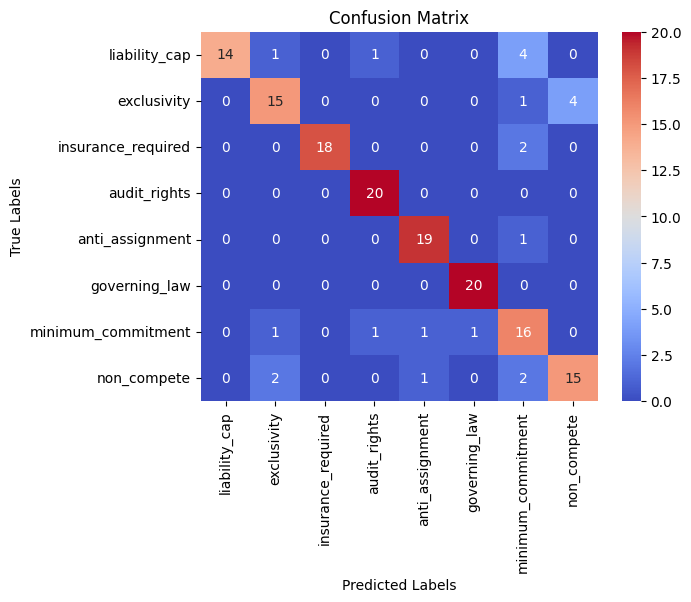

In [34]:
acuracy, macro_f1 = evaluate_pred(list(test_ds["label"]), preds)

# Experiment 2

In [13]:
model_r16, tokenizer, trainer_stats = finetune_model(model_name = MODEL_NAME,
                                                    train_ds = converted_dataset,
                                                    r = 16,
                                                    lora_alpha = 16,
                                                    lora_dropout = 0,
                                                    target_modules = ["q_proj", "v_proj","k_proj","o_proj"],# "gate_proj", "up_proj", "down_proj"],
                                                    lr = 1e-4)

==((====))==  Unsloth 2026.6.9: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

...

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Sample rendered conversation:
{'text': "<|im_start|>system\nYou are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation from the following list: {'anti_assignment', 'exclusivity', 'insurance_required', 'governing_law', 'liability_cap', 'minimum_commitment', 'non_compete', 'audit_rights'}<|im_end|>\n<|im_start|>user\nIn the event of termination by either party in accordance with any of the provisions of this Agreement, neither party shall be liable to the other, because of such termination, for compensation, reimbursement or damages on account of the loss of prospective profits or anticipated sales or on account of expenditures, inventory, investments, leases or commitments in connection with the business or goodwill of E.piphany or HSNS.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nliability_cap<|im_end|>\n"}
Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/800 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 1,081,344 of 854,067,264 (0.13% trained)


Step,Training Loss
10,2.759773
20,2.372927
30,1.864137
40,1.287608
50,1.286485
60,1.141677
70,1.149920
80,1.212051
90,1.209603
100,1.061834


In [18]:
from tqdm import tqdm
preds = [predict(model_r16, tokenizer, test_ds[sample]) for sample in tqdm(range(len(test_ds)))]

100%|██████████| 160/160 [01:48<00:00,  1.47it/s]


Classification Report:
                    precision    recall  f1-score   support

   anti_assignment       0.95      0.95      0.95        20
      audit_rights       1.00      0.90      0.95        20
       exclusivity       0.89      0.85      0.87        20
     governing_law       1.00      1.00      1.00        20
insurance_required       1.00      0.90      0.95        20
     liability_cap       0.90      0.90      0.90        20
minimum_commitment       0.82      0.90      0.86        20
       non_compete       0.78      0.90      0.84        20

          accuracy                           0.91       160
         macro avg       0.92      0.91      0.91       160
      weighted avg       0.92      0.91      0.91       160

Confusion Matrix:


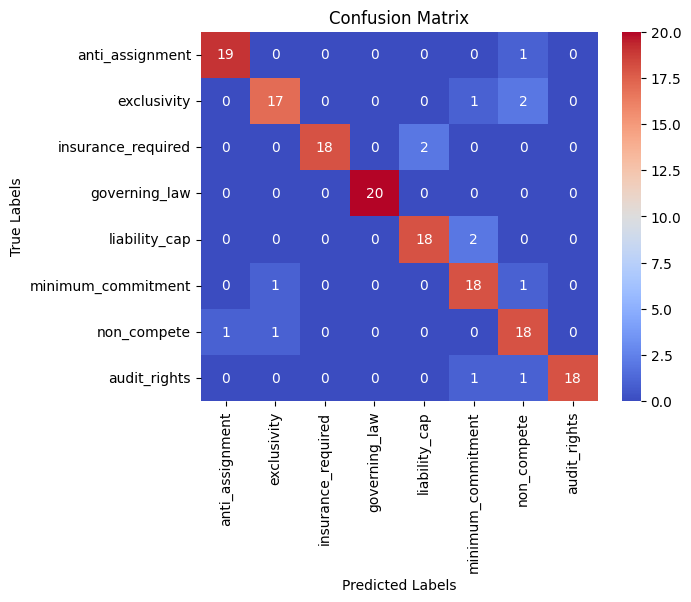

In [19]:
acuracy, macro_f1 = evaluate_pred(list(test_ds["label"]), preds)

# Experiment 3

In [24]:
model_all_tm, tokenizer, trainer_stats = finetune_model(model_name = MODEL_NAME,
                                                    train_ds = converted_dataset,
                                                    r = 16,
                                                    lora_alpha = 32,
                                                    lora_dropout = 0.1,
                                                    target_modules = ["q_proj", "v_proj","k_proj","o_proj", "gate_proj", "up_proj", "down_proj"],
                                                    lr = 1e-4)

==((====))==  Unsloth 2026.6.9: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.1.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Sample rendered conversation:
{'text': "<|im_start|>system\nYou are a legal assistant that classifies legal clauses into specific categories. Always output ONLY ONE category label without any explanation from the following list: {'anti_assignment', 'exclusivity', 'insurance_required', 'governing_law', 'liability_cap', 'minimum_commitment', 'non_compete', 'audit_rights'}<|im_end|>\n<|im_start|>user\nIn the event of termination by either party in accordance with any of the provisions of this Agreement, neither party shall be liable to the other, because of such termination, for compensation, reimbursement or damages on account of the loss of prospective profits or anticipated sales or on account of expenditures, inventory, investments, leases or commitments in connection with the business or goodwill of E.piphany or HSNS.<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nliability_cap<|im_end|>\n"}
Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/800 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 3 | Total steps = 600
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 6,389,760 of 859,375,680 (0.74% trained)


Step,Training Loss
10,2.275671
20,1.195831
30,1.155843
40,1.019871
50,1.160748
60,1.046163
70,1.078732
80,1.120569
90,1.129858
100,0.985438


In [27]:
from tqdm import tqdm
preds = [predict(model_all_tm, tokenizer, test_ds[sample]) for sample in tqdm(range(len(test_ds)))]

100%|██████████| 160/160 [01:24<00:00,  1.89it/s]


Classification Report:
                    precision    recall  f1-score   support

   anti_assignment       0.86      0.95      0.90        20
      audit_rights       0.95      0.90      0.92        20
       exclusivity       0.81      0.85      0.83        20
     governing_law       1.00      1.00      1.00        20
insurance_required       1.00      1.00      1.00        20
     liability_cap       0.95      0.95      0.95        20
minimum_commitment       0.89      0.80      0.84        20
       non_compete       0.75      0.75      0.75        20

          accuracy                           0.90       160
         macro avg       0.90      0.90      0.90       160
      weighted avg       0.90      0.90      0.90       160

Confusion Matrix:


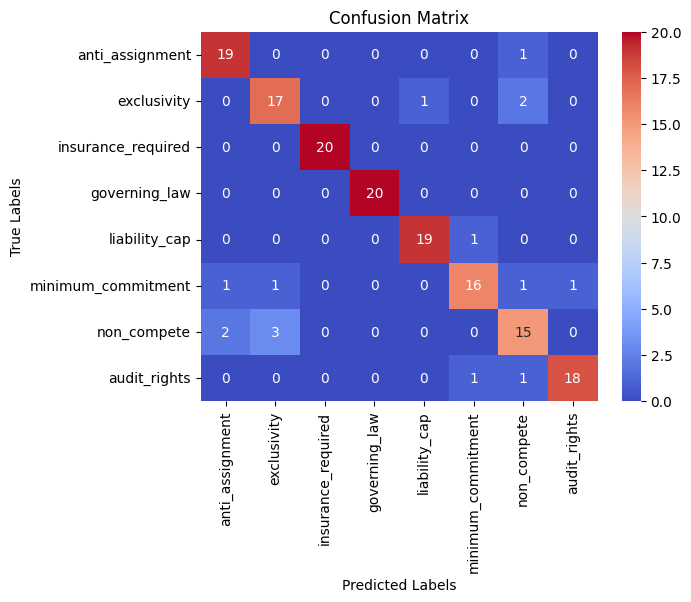

In [29]:
acuracy, macro_f1 = evaluate_pred(list(test_ds["label"]), preds)